**import libraries**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import  mean_squared_error, mean_absolute_error ,r2_score


**import dataset from kagglehub**

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/middle-east-country-wars")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'middle-east-country-wars' dataset.
Path to dataset files: /kaggle/input/middle-east-country-wars


**read dataset and explore it**

In [59]:
df=pd.read_csv('/root/.cache/kagglehub/datasets/willianoliveiragibin/middle-east-country-wars/versions/1/MiddleEast_2015-2024_Nov01.csv')
df


,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
0,PSE62716,2024-11-01,2024,1,Strategic developments,Strategic developments,Looting/property destruction,Settlers (Israel),NaN,Political militia,...,Shi'b Al Batim,31.3942,35.1365,1,PLO Negotiations Affairs Department,Other,"Land seizure: On 1 November 2024, Israeli sett...",0,NaN,1730758098
1,YEM93235,2024-11-01,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Yemen),Government of Yemen (2017-) Houthi,Protesters,...,Dawran ad Daydah,14.7393,44.2066,2,Yemen News Agency (SABA) - Houthi,National,"On 1 November 2024, protesters held a large Ho...",0,crowd size=large,1730758099
2,YEM93304,2024-11-01,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Yemen),Government of Yemen (2017-) Houthi,Protesters,...,Uzlat Al Aqibah,13.8786,43.7357,2,Yemen News Agency (SABA) - Houthi,National,"On 1 November 2024, protesters held a large Ho...",0,crowd size=large,1730758099
3,YEM93309,2024-11-01,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Yemen),Government of Yemen (2017-) Houthi,Protesters,...,Al Junayd,14.0842,44.0575,1,Yemen News Agency (SABA) - Houthi,National,"On 1 November 2024, protesters held a large Ho...",0,crowd size=large,1730758099
4,YEM93315,2024-11-01,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Yemen),Government of Yemen (2017-) Houthi,Protesters,...,Uzlat Al Ajum,14.0936,43.9495,2,Yemen News Agency (SABA) - Houthi,National,"On 1 November 2024, protesters held a large Ho...",0,crowd size=large,1730758099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476224,YEM32562,2015-01-01,2015,1,Political violence,Explosions/Remote violence,Remote explosive/landmine/IED,Unidentified Armed Group (Yemen),NaN,Political militia,...,Shibam,15.9214,48.6362,1,Barakish; Hadarem; Yemen Data Project,Local partner-National,Three soldiers were reportedly injured in an I...,0,NaN,1690843540
476225,YEM32563,2015-01-01,2015,1,Political violence,Battles,Armed clash,Military Forces of Yemen (2012-2022) Hadi,NaN,State forces,...,Nakhla,15.6160,45.1987,1,Al Jazeera; AP; Barakish; Yemen Data Project; ...,Local partner-National,"On 1 January 2015, Islah-affiliated tribesmen ...",9,NaN,1690843540
476226,YEM32564,2015-01-01,2015,1,Political violence,Battles,Armed clash,Military Forces of Yemen (2012-2022) Hadi,NaN,State forces,...,As Suhayl,15.5469,45.1265,1,Al Jazeera; AP; Barakish; Yemen Data Project; ...,Local partner-National,"On 1 January 2015, Islah-affiliated tribesmen ...",9,NaN,1690843540
476227,YEM32559,2015-01-01,2015,1,Political violence,Battles,Armed clash,AQAP: Al Qaeda in the Arabian Peninsula,Popular Resistance,Rebel group,...,Al Qayfa,14.5322,44.8228,2,Barakish; Yemen Data Project,Local partner-National,Houthi forces clashed with armed tribesmen bac...,0,NaN,1695070249


**take sample from the dataset to speed up training /testing (data volume is huge)**

In [60]:
df = df.sample(frac=0.3, random_state=42)

**Initial Data Inspection**


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142869 entries, 77735 to 75814
Data columns (total 31 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   event_id_cnty       142869 non-null  object 
 1   event_date          142869 non-null  object 
 2   year                142869 non-null  int64  
 3   time_precision      142869 non-null  int64  
 4   disorder_type       142869 non-null  object 
 5   event_type          142869 non-null  object 
 6   sub_event_type      142869 non-null  object 
 7   actor1              142869 non-null  object 
 8   assoc_actor_1       41368 non-null   object 
 9   inter1              142869 non-null  object 
 10  actor2              79572 non-null   object 
 11  assoc_actor_2       16135 non-null   object 
 12  inter2              79572 non-null   object 
 13  interaction         142869 non-null  object 
 14  civilian_targeting  19910 non-null   object 
 15  iso                 142869 non-null 

In [62]:
df.describe(include='all')

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,location,latitude,longitude,geo_precision,source,source_scale,notes,fatalities,tags,timestamp
count,142869,142869,142869.000000,142869.000000,142869,142869,142869,142869,41368,142869,...,142869,142869.000000,142869.000000,142869.000000,142869,142869,142869,142869.000000,38076,1.428690e+05
unique,142869,3578,NaN,NaN,4,6,25,1153,4341,8,...,11357,NaN,NaN,NaN,10566,25,139467,NaN,501,NaN
top,PSE44273,2023-10-18,NaN,NaN,Political violence,Explosions/Remote violence,Peaceful protest,Military Forces of Syria (2000-),Labor Group (Iran),State forces,...,Hays,NaN,NaN,NaN,SOHR,National,Coalition airstrikes hit unknown in Sirwah,NaN,crowd size=no report,NaN
freq,1,160,NaN,NaN,92882,56370,30526,13135,3520,34767,...,598,NaN,NaN,NaN,14957,45280,33,NaN,30564,NaN
mean,NaN,NaN,2020.205174,1.037139,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,30.401771,40.176757,1.392051,NaN,NaN,NaN,1.006376,NaN,1.700878e+09
std,NaN,NaN,2.665242,0.204195,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,8.199881,5.525824,0.548948,NaN,NaN,NaN,4.579834,NaN,3.746424e+07
min,NaN,NaN,2015.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.609000,25.876400,1.000000,NaN,NaN,NaN,0.000000,NaN,1.552576e+09
25%,NaN,NaN,2018.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,30.668200,35.813300,1.000000,NaN,NaN,NaN,0.000000,NaN,1.690844e+09
50%,NaN,NaN,2020.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,33.327800,39.401900,1.000000,NaN,NaN,NaN,0.000000,NaN,1.720478e+09
75%,NaN,NaN,2023.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,35.830200,44.109100,2.000000,NaN,NaN,NaN,0.000000,NaN,1.722899e+09


In [63]:
df.isnull().sum()

,0
event_id_cnty,0
event_date,0
year,0
time_precision,0
disorder_type,0
event_type,0
sub_event_type,0
actor1,0
assoc_actor_1,101501
inter1,0


حذف الاعمدة غير المهمة

In [64]:
df.drop(['event_id_cnty','notes','source','civilian_targeting','assoc_actor_1','assoc_actor_2','tags'], axis=1, inplace=True)
df

,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,inter1,actor2,inter2,...,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source_scale,fatalities,timestamp
77735,2023-12-04,2023,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),External/Other forces,Civilians (Palestine),Civilians,...,Gaza Strip,Deir El Balah,NaN,An Nusayrat,31.4486,34.3925,1,New media-National,1,1715641883
204952,2021-05-19,2021,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Iran),Political militia,Civilians (Iran),Civilians,...,Sistan and Baluchestan,Chabahar,Central,Chabahar,25.2919,60.6430,1,Other-International,1,1622485672
218848,2021-02-18,2021,1,Political violence,Violence against civilians,Abduction/forced disappearance,QSD: Syrian Democratic Forces,Rebel group,Civilians (Syria),Civilians,...,Deir ez Zor,Deir ez Zor,Basira,Al Sabkhah,35.2012,40.4263,2,New media,0,1720478699
241989,2020-08-25,2020,1,Political violence,Riots,Mob violence,Rioters (Palestine),Rioters,Military Forces of Israel (2009-2021),External/Other forces,...,West Bank,Nablus,NaN,Qaryut,32.0709,35.2940,1,Other,0,1715049876
339628,2018-09-14,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Iraq),Protesters,NaN,NaN,...,Al Basrah,Al Basrah,Markaz Al Basrah,Basrah,30.5330,47.7975,1,National,0,1650490673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226458,2020-12-21,2020,1,Demonstrations,Protests,Protest with intervention,Protesters (Israel),Protesters,Police Forces of Israel (2009-2021),State forces,...,Jerusalem,Jerusalem,Judean Mountains,Jerusalem,31.7690,35.2163,1,National,0,1722903299
106275,2023-07-04,2023,1,Demonstrations,Riots,Violent demonstration,Rioters (Palestine),Rioters,Military Forces of Israel (2022-),External/Other forces,...,West Bank,Al Quds,NaN,Al Quds - Ar Ram,31.8495,35.2342,1,Other-New media,0,1716328139
4146,2024-10-19,2024,1,Strategic developments,Strategic developments,Change to group/activity,Hezbollah,Political militia,NaN,NaN,...,Rural Damascus,Az Zabdani,Az Zabdani,Az-Zabdani,33.7252,36.1024,2,National,0,1730180202
37520,2024-06-05,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Syria),Protesters,NaN,NaN,...,As Sweida,Salkhad,Qarayya,Qarayya,32.5429,36.5962,1,New media-National,0,1720477751


handiling missing values

In [65]:
fill_null_col=['actor2', 'inter2', 'admin1', 'admin2', 'admin3']
df[fill_null_col] = df[fill_null_col].fillna('Unknown')
df

,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,inter1,actor2,inter2,...,admin1,admin2,admin3,location,latitude,longitude,geo_precision,source_scale,fatalities,timestamp
77735,2023-12-04,2023,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),External/Other forces,Civilians (Palestine),Civilians,...,Gaza Strip,Deir El Balah,Unknown,An Nusayrat,31.4486,34.3925,1,New media-National,1,1715641883
204952,2021-05-19,2021,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Iran),Political militia,Civilians (Iran),Civilians,...,Sistan and Baluchestan,Chabahar,Central,Chabahar,25.2919,60.6430,1,Other-International,1,1622485672
218848,2021-02-18,2021,1,Political violence,Violence against civilians,Abduction/forced disappearance,QSD: Syrian Democratic Forces,Rebel group,Civilians (Syria),Civilians,...,Deir ez Zor,Deir ez Zor,Basira,Al Sabkhah,35.2012,40.4263,2,New media,0,1720478699
241989,2020-08-25,2020,1,Political violence,Riots,Mob violence,Rioters (Palestine),Rioters,Military Forces of Israel (2009-2021),External/Other forces,...,West Bank,Nablus,Unknown,Qaryut,32.0709,35.2940,1,Other,0,1715049876
339628,2018-09-14,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Iraq),Protesters,Unknown,Unknown,...,Al Basrah,Al Basrah,Markaz Al Basrah,Basrah,30.5330,47.7975,1,National,0,1650490673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226458,2020-12-21,2020,1,Demonstrations,Protests,Protest with intervention,Protesters (Israel),Protesters,Police Forces of Israel (2009-2021),State forces,...,Jerusalem,Jerusalem,Judean Mountains,Jerusalem,31.7690,35.2163,1,National,0,1722903299
106275,2023-07-04,2023,1,Demonstrations,Riots,Violent demonstration,Rioters (Palestine),Rioters,Military Forces of Israel (2022-),External/Other forces,...,West Bank,Al Quds,Unknown,Al Quds - Ar Ram,31.8495,35.2342,1,Other-New media,0,1716328139
4146,2024-10-19,2024,1,Strategic developments,Strategic developments,Change to group/activity,Hezbollah,Political militia,Unknown,Unknown,...,Rural Damascus,Az Zabdani,Az Zabdani,Az-Zabdani,33.7252,36.1024,2,National,0,1730180202
37520,2024-06-05,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Syria),Protesters,Unknown,Unknown,...,As Sweida,Salkhad,Qarayya,Qarayya,32.5429,36.5962,1,New media-National,0,1720477751


In [66]:
df.isnull().sum()

,0
event_date,0
year,0
time_precision,0
disorder_type,0
event_type,0
sub_event_type,0
actor1,0
inter1,0
actor2,0
inter2,0


In [67]:
print(df.columns)


Index(['event_date', 'year', 'time_precision', 'disorder_type', 'event_type',
       'sub_event_type', 'actor1', 'inter1', 'actor2', 'inter2', 'interaction',
       'iso', 'region', 'country', 'admin1', 'admin2', 'admin3', 'location',
       'latitude', 'longitude', 'geo_precision', 'source_scale', 'fatalities',
       'timestamp'],
      dtype='object')


feature  extraction

In [68]:
df['event_date'] = pd.to_datetime(df['event_date'])

df['year'] = df['event_date'].dt.year
df['month'] = df['event_date'].dt.month
df['day'] = df['event_date'].dt.day

In [69]:
df.drop('event_date', axis=1, inplace=True)
df

,year,time_precision,disorder_type,event_type,sub_event_type,actor1,inter1,actor2,inter2,interaction,...,admin3,location,latitude,longitude,geo_precision,source_scale,fatalities,timestamp,month,day
77735,2023,1,Political violence,Explosions/Remote violence,Air/drone strike,Military Forces of Israel (2022-),External/Other forces,Civilians (Palestine),Civilians,External/Other forces-Civilians,...,Unknown,An Nusayrat,31.4486,34.3925,1,New media-National,1,1715641883,12,4
204952,2021,1,Political violence,Violence against civilians,Attack,Unidentified Armed Group (Iran),Political militia,Civilians (Iran),Civilians,Political militia-Civilians,...,Central,Chabahar,25.2919,60.6430,1,Other-International,1,1622485672,5,19
218848,2021,1,Political violence,Violence against civilians,Abduction/forced disappearance,QSD: Syrian Democratic Forces,Rebel group,Civilians (Syria),Civilians,Rebel group-Civilians,...,Basira,Al Sabkhah,35.2012,40.4263,2,New media,0,1720478699,2,18
241989,2020,1,Political violence,Riots,Mob violence,Rioters (Palestine),Rioters,Military Forces of Israel (2009-2021),External/Other forces,Rioters-External/Other forces,...,Unknown,Qaryut,32.0709,35.2940,1,Other,0,1715049876,8,25
339628,2018,1,Demonstrations,Protests,Peaceful protest,Protesters (Iraq),Protesters,Unknown,Unknown,Protesters only,...,Markaz Al Basrah,Basrah,30.5330,47.7975,1,National,0,1650490673,9,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226458,2020,1,Demonstrations,Protests,Protest with intervention,Protesters (Israel),Protesters,Police Forces of Israel (2009-2021),State forces,State forces-Protesters,...,Judean Mountains,Jerusalem,31.7690,35.2163,1,National,0,1722903299,12,21
106275,2023,1,Demonstrations,Riots,Violent demonstration,Rioters (Palestine),Rioters,Military Forces of Israel (2022-),External/Other forces,Rioters-External/Other forces,...,Unknown,Al Quds - Ar Ram,31.8495,35.2342,1,Other-New media,0,1716328139,7,4
4146,2024,1,Strategic developments,Strategic developments,Change to group/activity,Hezbollah,Political militia,Unknown,Unknown,Political militia only,...,Az Zabdani,Az-Zabdani,33.7252,36.1024,2,National,0,1730180202,10,19
37520,2024,1,Demonstrations,Protests,Peaceful protest,Protesters (Syria),Protesters,Unknown,Unknown,Protesters only,...,Qarayya,Qarayya,32.5429,36.5962,1,New media-National,0,1720477751,6,5


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142869 entries, 77735 to 75814
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            142869 non-null  int32  
 1   time_precision  142869 non-null  int64  
 2   disorder_type   142869 non-null  object 
 3   event_type      142869 non-null  object 
 4   sub_event_type  142869 non-null  object 
 5   actor1          142869 non-null  object 
 6   inter1          142869 non-null  object 
 7   actor2          142869 non-null  object 
 8   inter2          142869 non-null  object 
 9   interaction     142869 non-null  object 
 10  iso             142869 non-null  int64  
 11  region          142869 non-null  object 
 12  country         142869 non-null  object 
 13  admin1          142869 non-null  object 
 14  admin2          142869 non-null  object 
 15  admin3          142869 non-null  object 
 16  location        142869 non-null  object 
 17  latitude    

التعرف على القيم ال (unique) في  كل عمود

In [71]:
df['disorder_type'].unique()

array(['Political violence', 'Demonstrations', 'Strategic developments',
       'Political violence; Demonstrations'], dtype=object)

In [72]:
df['event_type'].unique()

array(['Explosions/Remote violence', 'Violence against civilians',
       'Riots', 'Protests', 'Strategic developments', 'Battles'],
      dtype=object)

In [73]:
df['sub_event_type'].unique()

array(['Air/drone strike', 'Attack', 'Abduction/forced disappearance',
       'Mob violence', 'Peaceful protest',
       'Shelling/artillery/missile attack',
       'Remote explosive/landmine/IED', 'Protest with intervention',
       'Change to group/activity', 'Other', 'Violent demonstration',
       'Armed clash', 'Looting/property destruction',
       'Non-state actor overtakes territory', 'Grenade',
       'Disrupted weapons use', 'Government regains territory',
       'Suicide bomb', 'Arrests', 'Excessive force against protesters',
       'Agreement', 'Non-violent transfer of territory',
       'Headquarters or base established', 'Chemical weapon',
       'Sexual violence'], dtype=object)

In [74]:
df['actor1'].unique()

array(['Military Forces of Israel (2022-)',
       'Unidentified Armed Group (Iran)', 'QSD: Syrian Democratic Forces',
       ..., 'Al Hujayra Tribal Militia (Yemen)',
       'Mweileh Communal Militia (Syria)', 'Ojeil Tribal Militia (Syria)'],
      dtype=object)

In [75]:
df['actor2'].unique()

array(['Civilians (Palestine)', 'Civilians (Iran)', 'Civilians (Syria)',
       ..., 'Al Nasiri Tribal Militia (Yemen)',
       'Mweileh Communal Militia (Syria)', 'Civilians (South Korea)'],
      dtype=object)

In [76]:
df['inter1'].unique()

array(['External/Other forces', 'Political militia', 'Rebel group',
       'Rioters', 'Protesters', 'State forces', 'Identity militia',
       'Civilians'], dtype=object)

In [77]:
df['inter2'].unique()

array(['Civilians', 'External/Other forces', 'Unknown', 'State forces',
       'Rebel group', 'Rioters', 'Political militia', 'Identity militia',
       'Protesters'], dtype=object)

In [78]:
df['interaction'].unique()

array(['External/Other forces-Civilians', 'Political militia-Civilians',
       'Rebel group-Civilians', 'Rioters-External/Other forces',
       'Protesters only', 'Political militia only', 'State forces only',
       'State forces-State forces', 'State forces-Protesters',
       'External/Other forces only', 'Rebel group-External/Other forces',
       'Rioters only', 'State forces-Political militia',
       'Political militia-External/Other forces',
       'Rebel group-Rebel group', 'State forces-External/Other forces',
       'State forces-Civilians', 'State forces-Rebel group',
       'Political militia-Identity militia',
       'Political militia-Political militia',
       'Rebel group-Political militia', 'Rioters-Rioters',
       'Civilians only', 'Identity militia-Identity militia',
       'State forces-Rioters', 'Protesters-External/Other forces',
       'Rebel group-Identity militia', 'Rebel group-Protesters',
       'Rioters-Civilians', 'Rebel group only', 'Identity militia on

In [79]:
df['region'].unique()

array(['Middle East'], dtype=object)

In [80]:
df['country'].unique()

array(['Palestine', 'Iran', 'Syria', 'Iraq', 'Israel', 'Yemen', 'Bahrain',
       'Lebanon', 'Jordan', 'Turkey', 'Saudi Arabia',
       'United Arab Emirates', 'Kuwait', 'Oman', 'Qatar'], dtype=object)

In [81]:
df['admin1'].unique()

array(['Gaza Strip', 'Sistan and Baluchestan', 'Deir ez Zor', 'West Bank',
       'Al Basrah', 'HaZafon', 'Hama', 'Sadah', 'Northern', 'Idleb',
       'Duhok', 'Taizz', 'Mount Lebanon', 'Rural Damascus', 'Ad Dali',
       'Tehran', 'Homs', 'Al Hudaydah', 'Kirkuk', 'Maan', 'Erbil',
       'Aleppo', 'Al Hasakeh', 'South', 'Istanbul', 'Gilan', 'Hajjah',
       'Al Bayda', 'Diyarbakir', 'Markazi', 'Shabwah', 'Al Anbar',
       'Az Zarqa', 'Dara', 'Izmir', 'Jizan', 'Maysan', 'Amran', 'Sanaa',
       'Hadramawt', 'HaMerkaz', 'Irbid', 'Adana', 'Malatya', 'Lattakia',
       'Ibb', 'Al Nabatieh', 'Tunceli', 'Haifa', 'Baalbek-Hermel',
       'Alborz', 'Sirnak', 'Ar Riyadh', 'Lahij', 'Khuzestan', 'Ilam',
       'HaDarom', 'Capital', 'Artvin', 'Baghdad', 'Al Jawf', 'Mardin',
       'Ardabil', 'Mersin', 'North', 'Kirklareli', 'East Azerbaijan',
       'Ninewa', 'Southern', 'Bekaa', 'Akkar', 'Al Muthanna',
       'West Azerbaijan', 'Thi Qar', 'Marib', 'Quneitra', 'Aden',
       'Hakkari', 'Abu Dhabi

In [82]:
df['admin2'].unique()

array(['Deir El Balah', 'Chabahar', 'Deir ez Zor', ..., 'Farahan',
       'Bozkir', 'Elbeyli'], dtype=object)

In [83]:
df['location'].unique()

array(['An Nusayrat', 'Chabahar', 'Al Sabkhah', ..., 'Uzlat Bani Sawi',
       'Balikli', 'Mitzpe Hagit'], dtype=object)

In [84]:
df['source_scale'].unique()

array(['New media-National', 'Other-International', 'New media', 'Other',
       'National', 'Local partner-New media', 'Local partner-National',
       'National-International', 'Other-Subnational',
       'Local partner-Other', 'Other-New media', 'Subnational',
       'International', 'Other-National', 'Regional-International',
       'Subnational-National', 'Local partner-Regional',
       'National-Regional', 'Regional', 'Other-Regional',
       'New media-Regional', 'Subnational-International',
       'Subnational-Regional', 'New media-International',
       'New media-Subnational'], dtype=object)

In [85]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, "# unique value : ", df[col].nunique())

disorder_type # unique value :  4
event_type # unique value :  6
sub_event_type # unique value :  25
actor1 # unique value :  1153
inter1 # unique value :  8
actor2 # unique value :  1043
inter2 # unique value :  9
interaction # unique value :  42
region # unique value :  1
country # unique value :  15
admin1 # unique value :  231
admin2 # unique value :  1569
admin3 # unique value :  723
location # unique value :  11357
source_scale # unique value :  25


حذف الاعمدة غير المهمة

In [86]:
df.drop('location', axis=1, inplace=True)
df.drop('admin3', axis=1, inplace=True)

In [87]:
df.drop('admin2', axis=1, inplace=True)

In [88]:
df.drop('time_precision', axis=1, inplace=True)

عرض النيومركال فيتشرز لكشف الاوتلايرز

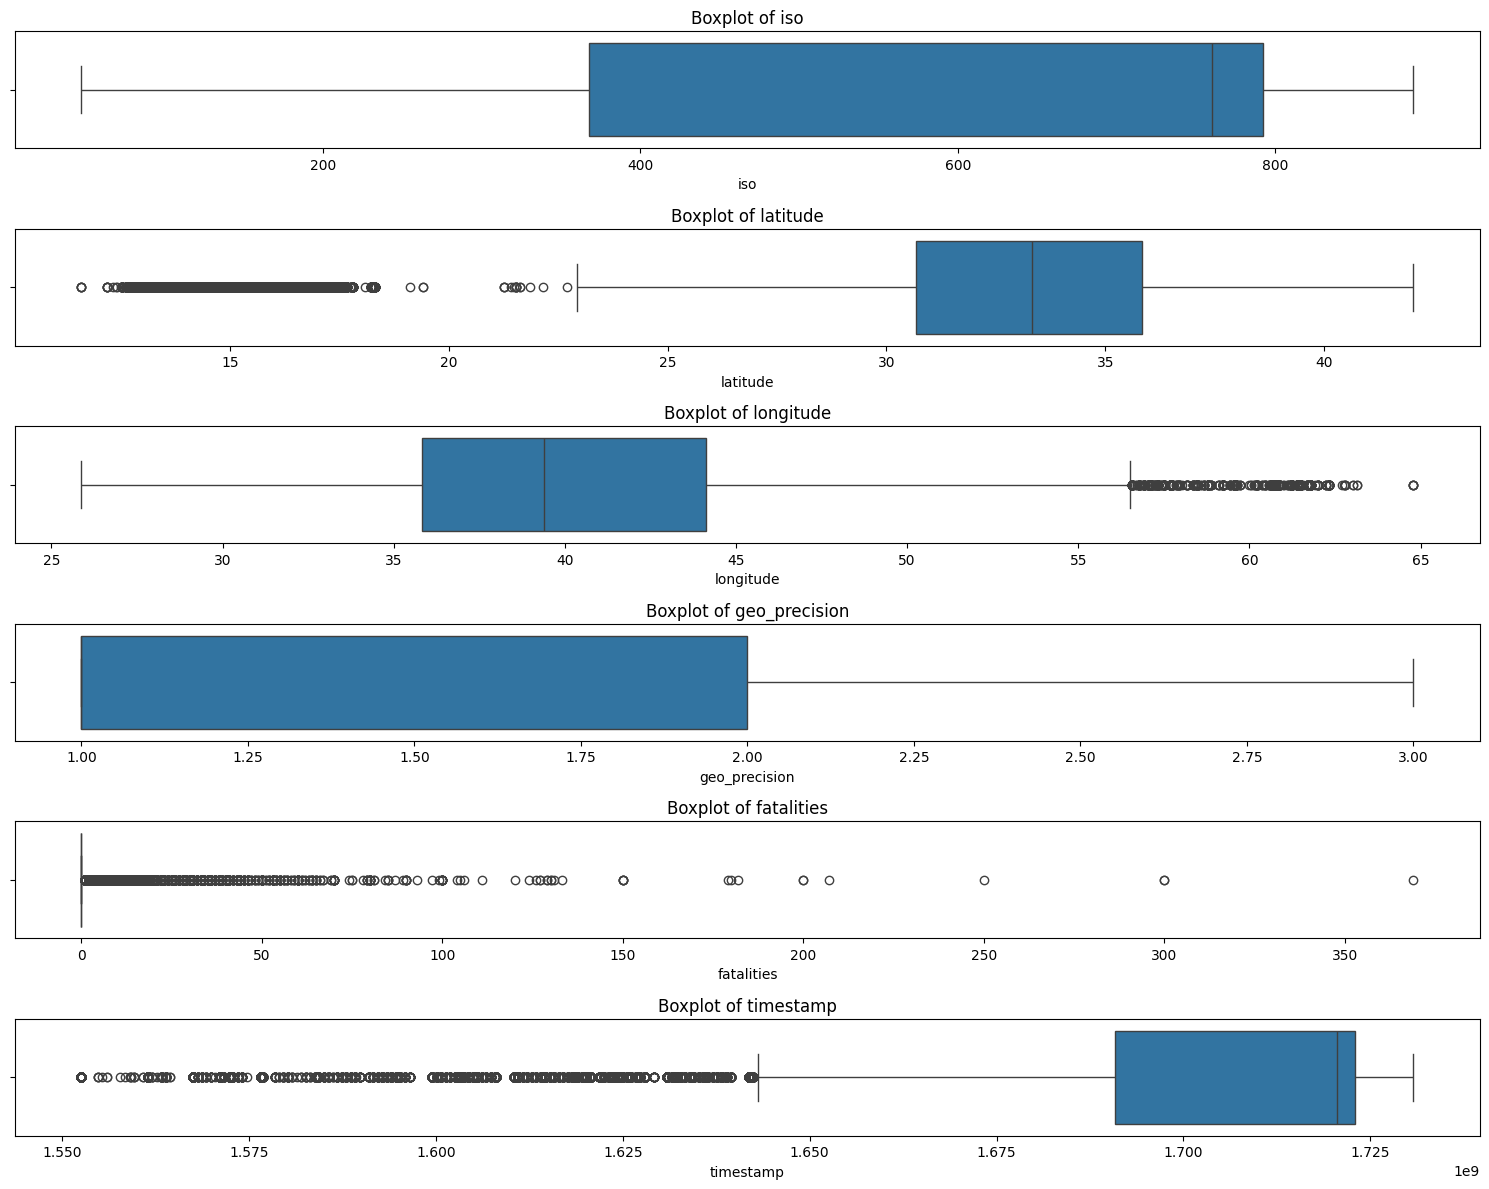

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns


num_cols = df.select_dtypes(include=['int64','float64']).columns


plt.figure(figsize=(15, len(num_cols)*2))


for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [90]:
df.drop('timestamp', axis=1, inplace=True)

تقسيم الداتا

In [91]:

X = df.drop('fatalities', axis=1)
y = df['fatalities']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

**encoding for categorical columns**

In [92]:

categorical_cols = X_train.select_dtypes(include='object').columns
print("Categorical columns:", categorical_cols)

# One-Hot: ≤10
one_hot_cols = [col for col in categorical_cols if X_train[col].nunique() <= 10]

# Frequency Encoding: 10-50
freq_cols = [col for col in categorical_cols if 10 < X_train[col].nunique() <= 50]

# Target Encoding: >50
target_cols = [col for col in categorical_cols if X_train[col].nunique() > 50]

print("One-Hot Encoding:", one_hot_cols)
print("Frequency Encoding:", freq_cols)
print("Target Encoding:", target_cols)

Categorical columns: Index(['disorder_type', 'event_type', 'sub_event_type', 'actor1', 'inter1',
       'actor2', 'inter2', 'interaction', 'region', 'country', 'admin1',
       'source_scale'],
      dtype='object')
One-Hot Encoding: ['disorder_type', 'event_type', 'inter1', 'inter2', 'region']
Frequency Encoding: ['sub_event_type', 'interaction', 'country', 'source_scale']
Target Encoding: ['actor1', 'actor2', 'admin1']


In [93]:
X_train = pd.get_dummies(X_train, columns=one_hot_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=one_hot_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [94]:
for col in freq_cols:
    freq = X_train[col].value_counts(normalize=True)

    X_train[col + '_freq'] = X_train[col].map(freq)
    # Fill NaNs for categories in X_test not present in X_train with 0
    X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)

    X_train.drop(col, axis=1, inplace=True)
    X_test.drop(col, axis=1, inplace=True)

In [95]:
for col in target_cols:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    X_train[col + '_encoded_target'] = 0

    for train_indices, validation_indices in kf.split(X_train):
        mean_target = y_train.iloc[train_indices].groupby(X_train.iloc[train_indices][col]).mean()
        X_train.iloc[validation_indices, X_train.columns.get_loc(col + '_encoded_target')] = X_train.iloc[validation_indices][col].map(mean_target)

    global_mean = y_train.mean()

    X_test[col + '_encoded_target'] = X_test[col].map(X_train.groupby(col)[col + '_encoded_target'].mean()).fillna(global_mean)



    X_train.drop(col, axis=1, inplace=True)
    X_test.drop(col, axis=1, inplace=True)



/tmp/ipykernel_11490/3361929388.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.71666553 0.00146853 0.23586118 ... 0.19439391 0.         0.24093797]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.iloc[validation_indices, X_train.columns.get_loc(col + '_encoded_target')] = X_train.iloc[validation_indices][col].map(mean_target)
/tmp/ipykernel_11490/3361929388.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.52178142 0.00161202 0.55141867 ... 0.55141867 0.00161202 0.53970935]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.iloc[validation_indices, X_train.columns.get_loc(col + '_encoded_target')] = X_train.iloc[validation_indices][col].map(mean_target)
/tmp/ipykernel_11490/3361929388.py:7: FutureWarning: Setting a

handiling outliers (after encoding categorical) & numerical features


cliping for x

In [96]:

cols_to_clip = ['latitude','longitude','interaction_freq','actor1_encoded_target',
                    'actor2_encoded_target','admin1_encoded_target']

for col in cols_to_clip:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_test[col] = X_test[col].clip(lower_bound, upper_bound)

cliping for y

In [97]:
"""Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

y_train = y_train.clip(lower_bound, upper_bound)"""

'Q1 = y_train.quantile(0.25)\nQ3 = y_train.quantile(0.75)\nIQR = Q3 - Q1\nlower_bound = Q1 - 1.5 * IQR\nupper_bound = Q3 + 1.5 * IQR\n\ny_train = y_train.clip(lower_bound, upper_bound)'

In [98]:

num_cols = X_train.select_dtypes(include=['int64','float64']).columns


for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]

    print(f"{col}:")
    print(f"  # outliers {len(outliers)}")
    print(f"  Lower bound: {lower_bound}, Upper bound: {upper_bound}\n")

iso:
  # outliers 0
  Lower bound: -268.0, Upper bound: 1428.0

latitude:
  # outliers 0
  Lower bound: 22.938100000000002, Upper bound: 43.5517

longitude:
  # outliers 0
  Lower bound: 23.394199999999998, Upper bound: 56.5142

geo_precision:
  # outliers 0
  Lower bound: -0.5, Upper bound: 3.5

sub_event_type_freq:
  # outliers 0
  Lower bound: -0.16027385274946412, Upper bound: 0.3803972177260598

interaction_freq:
  # outliers 0
  Lower bound: -0.05821776980620325, Upper bound: 0.18683231987401025

country_freq:
  # outliers 0
  Lower bound: -0.21733234174723304, Upper bound: 0.5760531956778512

source_scale_freq:
  # outliers 0
  Lower bound: -0.316991119471543, Upper bound: 0.6979614156349797

actor1_encoded_target:
  # outliers 0
  Lower bound: -0.5663551268490733, Upper bound: 0.9517783057424947

actor2_encoded_target:
  # outliers 0
  Lower bound: -0.812783741401802, Upper bound: 1.3592471076398807

admin1_encoded_target:
  # outliers 0
  Lower bound: -0.5404415761372744, Uppe

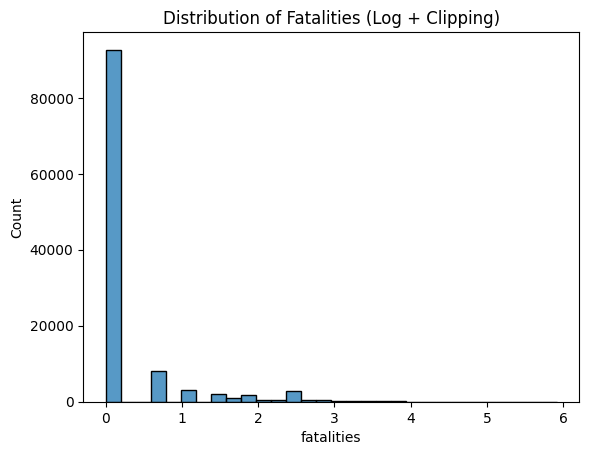

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y_train, bins=30)
plt.title("Distribution of Fatalities (Log + Clipping)")
plt.show()

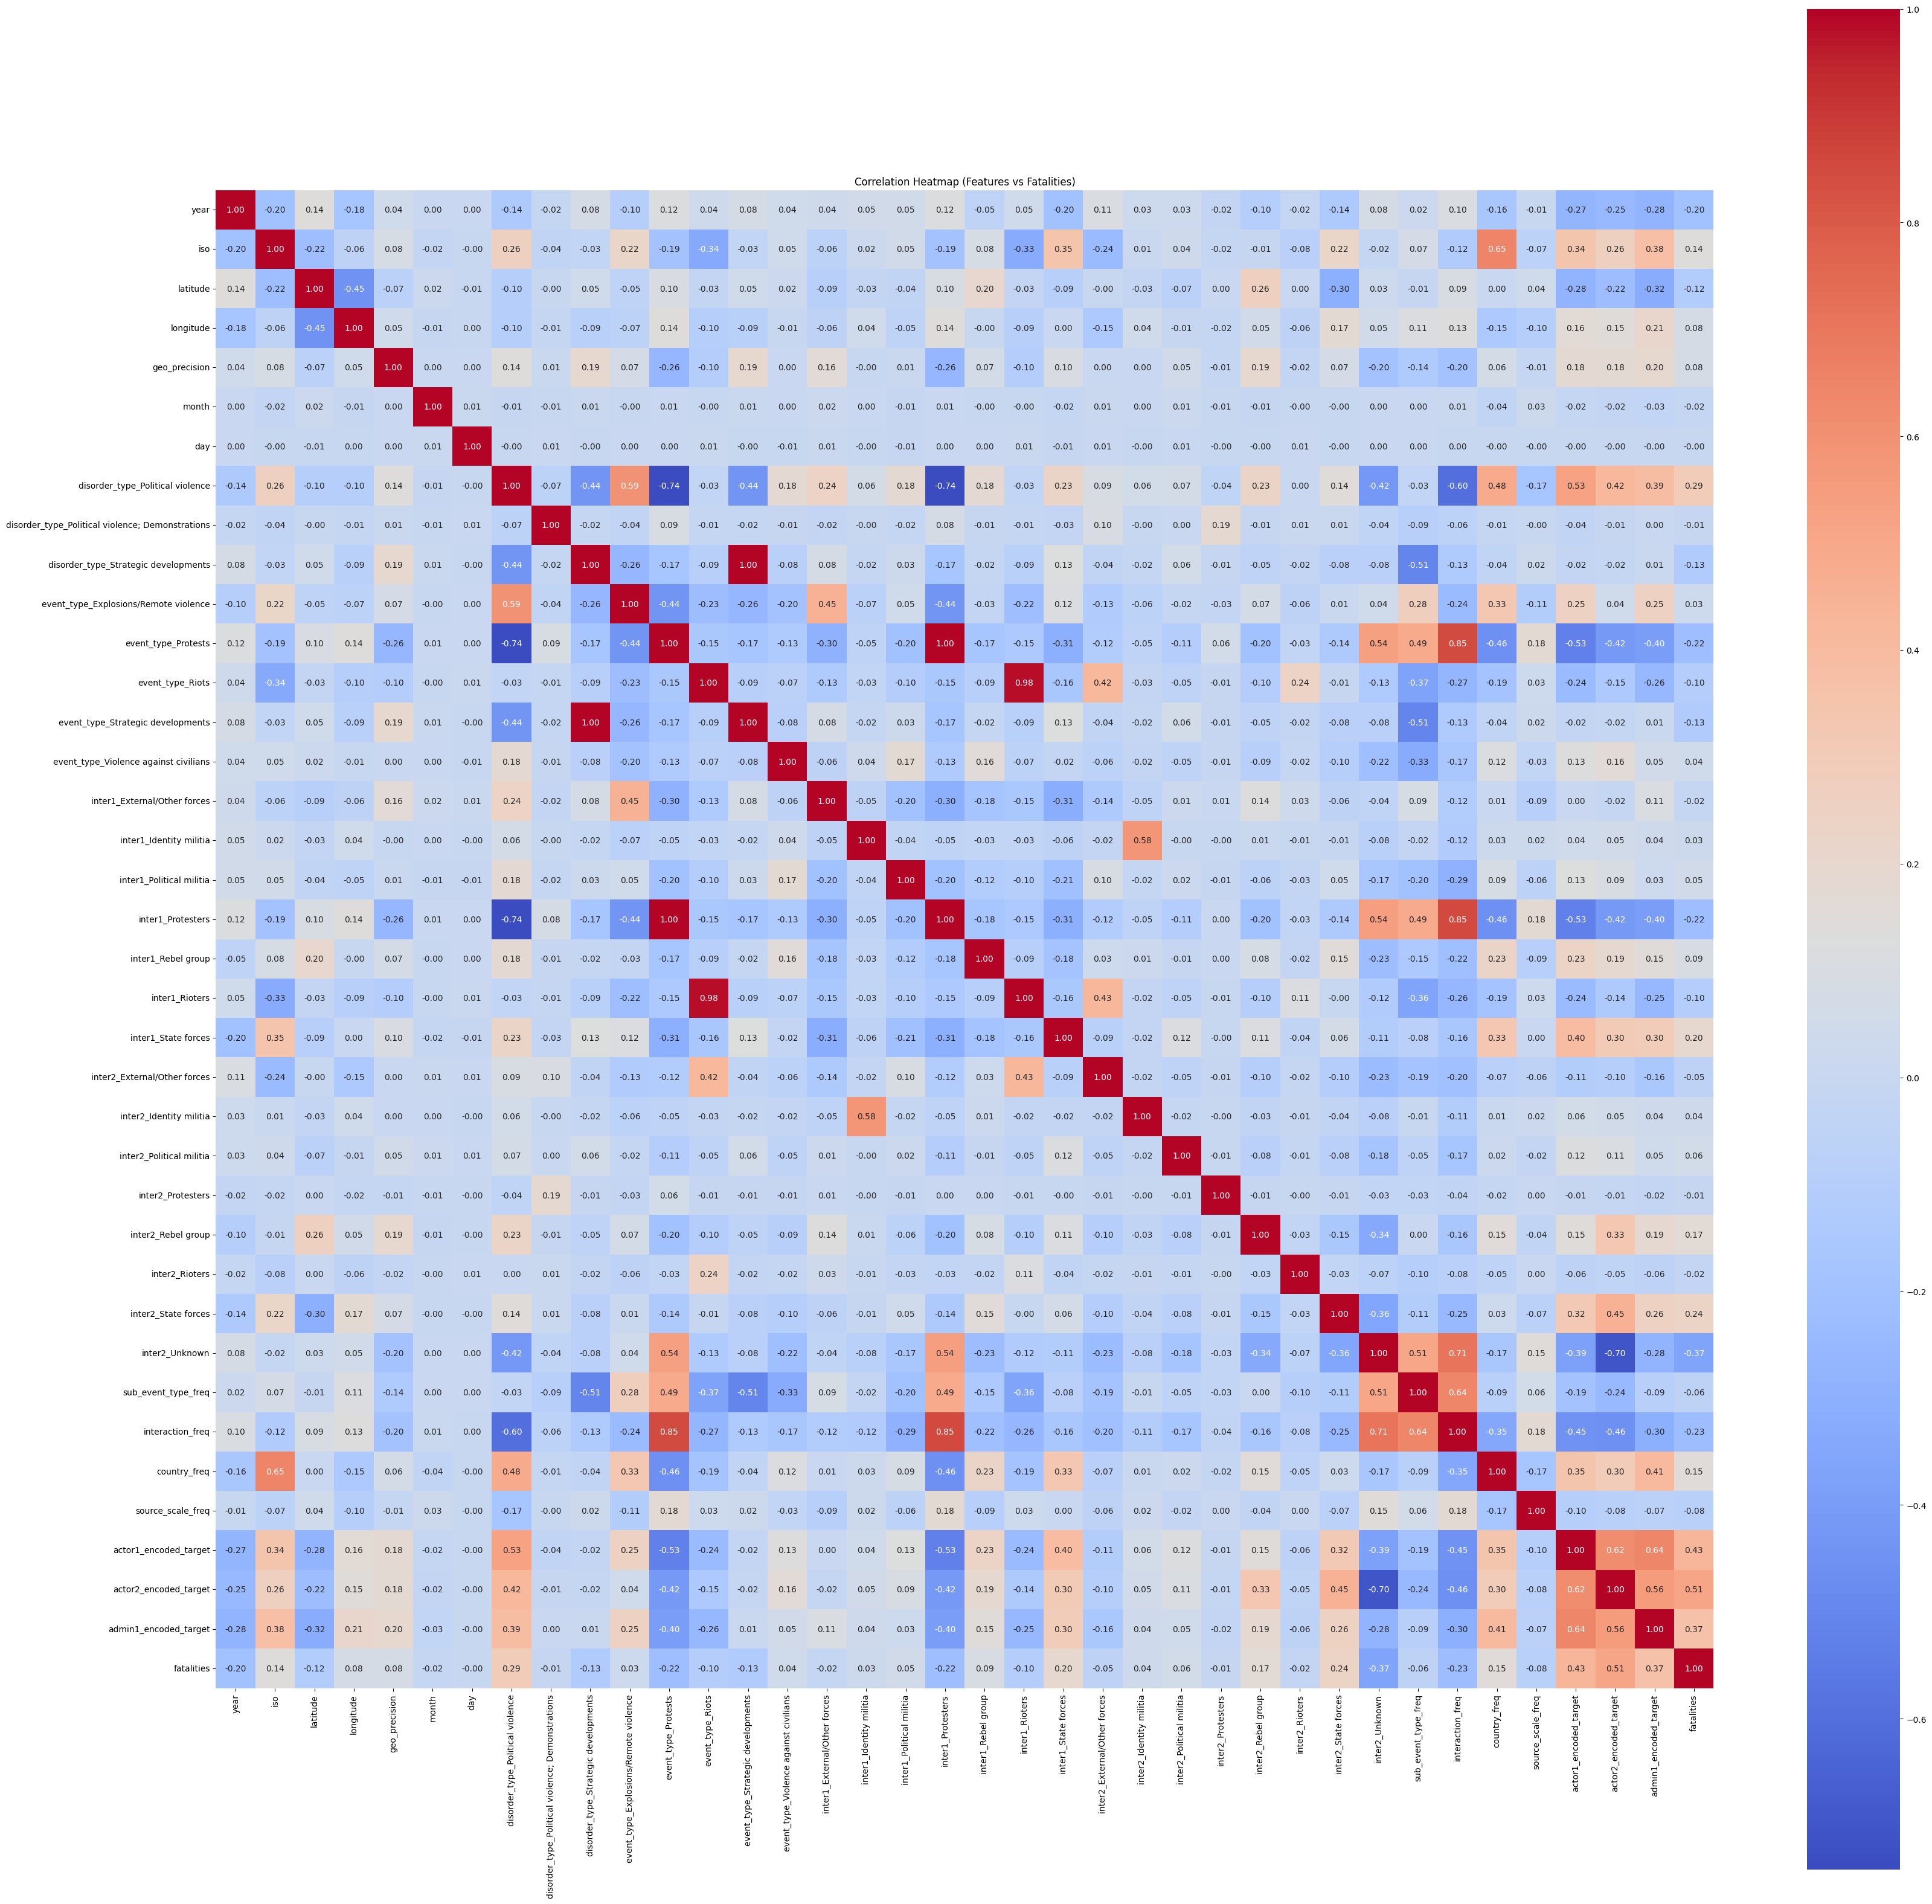

In [100]:
X_encoded = pd.DataFrame(X_train, columns=X_train.columns)
y_encoded = pd.Series(y_train, name='fatalities')


df_encoded = pd.concat([X_encoded, y_encoded], axis=1)

corr_matrix = df_encoded.corr()


plt.figure(figsize=(40,40))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title("Correlation Heatmap (Features vs Fatalities)")
plt.show()

In [101]:

X_train = pd.DataFrame(X_train, columns=X_encoded.columns)
X_test = pd.DataFrame(X_test, columns=X_encoded.columns)

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = X_train[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_test[num_cols] = X_test[num_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

**deploying models**

In [102]:
X_train_df = X_train.copy()
X_test_df = X_test.copy()


X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns = X_test.columns.str.replace(' ', '_')


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

MSE: 0.2865592285880343
MAE: 0.3106869468723344
R^2 Score: 0.3356777641926959


In [103]:
dt_model = DecisionTreeRegressor(max_depth=15, min_samples_leaf=7, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("R^2 Score:", r2_score(y_test, y_pred_dt))

MSE: 0.2610765928056408
MAE: 0.22142329103689765
R^2 Score: 0.39475344519810507


In [104]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_df, y_train)
y_pred_rf= rf_model.predict(X_test_df)

print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))


MSE: 0.2215338805087647
MAE: 0.2108474686725763
R2: 0.48642420789655894


In [105]:

importances = pd.Series(rf_model.feature_importances_, index=X_train_df.columns)
print(importances.sort_values(ascending=False).head(15))

actor2_encoded_target                    0.298710
longitude                                0.100021
actor1_encoded_target                    0.098712
day                                      0.086892
admin1_encoded_target                    0.064647
sub_event_type_freq                      0.061148
month                                    0.061016
latitude                                 0.050689
source_scale_freq                        0.048322
year                                     0.043985
interaction_freq                         0.018498
geo_precision                            0.017975
disorder_type_Political violence         0.007569
event_type_Explosions/Remote violence    0.005090
disorder_type_Strategic developments     0.004143
dtype: float64


In [106]:
gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)


print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("R2:", r2_score(y_test, y_pred_gb))

MSE: 0.25045525455891493
MAE: 0.2608305069697698
R2: 0.4193765962517201


the worst model is poissoon


In [107]:


poisson_model = PoissonRegressor(alpha=1.0, max_iter=1000)
poisson_model.fit(X_train, y_train)

y_pred_poisson = poisson_model.predict(X_test)

print("Poisson R2:", r2_score(y_test, y_pred_poisson))
print("Poisson MAE:", mean_absolute_error(y_test, y_pred_poisson))
print("Poisson MSE:", mean_squared_error(y_test, y_pred_poisson))

Poisson R2: -2.9721717574426876e-05
Poisson MAE: 0.4412421158935644
Poisson MSE: 0.4313685891790888


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


In [108]:

xgb_model = XGBRegressor(n_estimators=200,max_depth=6,learning_rate=0.1)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGB R2:", r2_score(y_test, y_pred_xgb))

XGB R2: 0.4844801837980932


In [109]:

lgb = LGBMRegressor()

param_dist = {'n_estimators': [100, 200, 300],'learning_rate': [0.01, 0.05, 0.1],'max_depth': [-1, 5, 10],
              'num_leaves': [31, 50],'subsample': [0.8, 1.0],'colsample_bytree': [0.8, 1.0]}

random_search = RandomizedSearchCV(lgb, param_distributions=param_dist,n_iter=10,
                                     scoring='r2', cv=3,random_state=42,n_jobs=-1)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)


y_pred_best = best_model.predict(X_test)

print("Tuned R2:", r2_score(y_test, y_pred_best))
print("Tuned MAE:", mean_absolute_error(y_test, y_pred_best))
print("Tuned MSE:", mean_squared_error(y_test, y_pred_best))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 114295, number of used features: 37
[LightGBM] [Info] Start training from score 0.274415
Best Params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Tuned R2: 0.4889265741425983
Tuned MAE: 0.22478450593126217
Tuned MSE: 0.22045447039352395


**comparison between models **

In [111]:

results = {
    "Linear Regression": r2,
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Random Forest": r2_score(y_test, y_pred_rf),
    "Gradient Boosting": r2_score(y_test, y_pred_gb),
    "XGBoost": r2_score(y_test, y_pred_xgb),
    "LightGBM": r2_score(y_test, y_pred_best) }

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['R2'])

print(results_df)

                         R2
Linear Regression  0.335678
Decision Tree      0.394753
Random Forest      0.486424
Gradient Boosting  0.419377
XGBoost            0.484480
LightGBM           0.488927


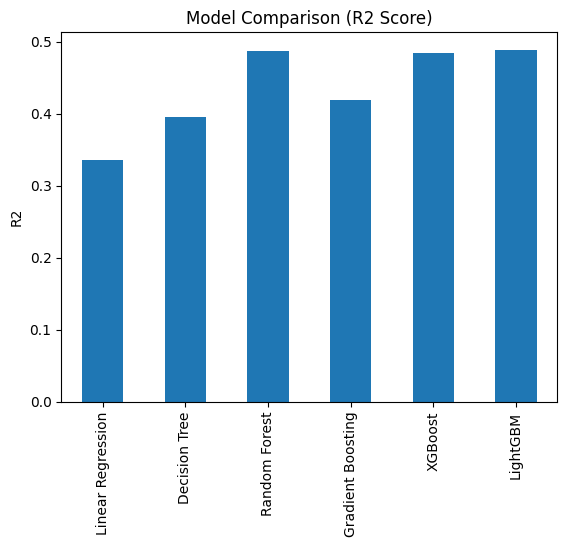

In [112]:
results_df.plot(kind='bar', legend=False)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2")
plt.show()